<a href="https://colab.research.google.com/github/SRXKaiser/analitica-de-datos/blob/main/Victor/Actividad2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTITUTO TECNOLOGICO DE CIUDAD JUAREZ**

**Ciencia y analítica de datos**

MODELOS DE APRENDIZAJE


**ACTIVIDAD 2**
Exploración de datos

---

*   NOMBRE: Victor Manuel Landeros Ramirez
*   NO. CONTROL: 23111511

-------

# CODIGO PARA ACCEDER A NUESTRO DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# IMPORTA LAS LIBRERIAS NECESARIAS

In [2]:
#libreria manipulacion de datos
import pandas as pd


#libreria para calculos numericos y estadisticos
import numpy as np


#libreria para graficos
import matplotlib.pyplot as plt
import seaborn as sns




# CONVIERTE ARCHIVO CSV A TIPO DataFrame (df)

In [8]:
credit_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_risk_dataset.csv')
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


----

# **Parte 1**. Análisis descriptivo (univariante)

1. Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas cualitativas?

<font color="orange">8 columnas numericas y 4 columnas cualitativas.</FONT>

In [9]:
#.info()muestra la informacion del dataframe numero de columnas y del tipo de dato de cada una de las columnas
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


 2. Determina el porcentaje de valores faltantes por columna.

In [10]:
#.isna() revisa si existen valores nulos
#.mean() calcula promedio
porcent = credit_df.isna().mean() *100
porcent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


----

# Análisis de variables numéricas

3. Obtén las siguientes estadísticas descriptivas para todas las variables numéricas:
*   Tendencia central (media, mediana)
*   Dispersión o variabilidad (min, max, desviación estándar, cuartiles)
*   Forma (asimetría y curtosis)
*   Clasifica las variables `person_age` y `loan_in_rate` según los valores observados de asimetría y curtosis

**NOTA**. Recuerda que muchas de estas estadísticas, puedes obtenerlas utilizando la función `describe()` y que la mediana está representada en el 2do cuartil (50%)

#

In [11]:
#Tendencia central (media, mediana)
#Dispersion o variabilidad (min, max, desviación estándar, cuartiles)
num = credit_df.select_dtypes(include='number')
num.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
#Forma (Asimetria y Kurtosis)
forma = pd.DataFrame({
    'Asimetría': num.skew(),
    'Curtosis': num.kurtosis()
})

forma

,Asimetría,Curtosis
person_age,2.581393,18.560825
person_income,32.865349,2693.272776
person_emp_length,2.614455,43.722338
loan_amnt,1.192477,1.423565
loan_int_rate,0.208550,-0.671609
loan_status,1.364888,-0.137088
loan_percent_income,1.064669,1.223687
cb_person_cred_hist_length,1.661790,3.716194


In [13]:
forma.loc[['person_age', 'loan_int_rate']]

,Asimetría,Curtosis
person_age,2.581393,18.560825
loan_int_rate,0.208550,-0.671609


------

4. Utiliza histogramas para determinar la distribución de los valores representados en cada variable.
*   ¿Se corresponde con lo obtenido en el cálculo de asimetría? Como verás, los datos reales son más complejos que la teoría. Por esta razón, recuerda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma.

**NOTA**. Para esto también puedes ocupar los gráficos `kde` ([kernel density estimation](https://www.cienciadedatos.net/documentos/pystats02-kernel-density-estimation-kde-python.html)) que crean una curva continua y suave expandiendo la idea del histograma.

<font color="orange">Sí, en general coincide. Por ejemplo, en person_age se nota bastante la cola hacia la derecha, mientras que loan_int_rate se ve mucho mas equilibrada</FONT>

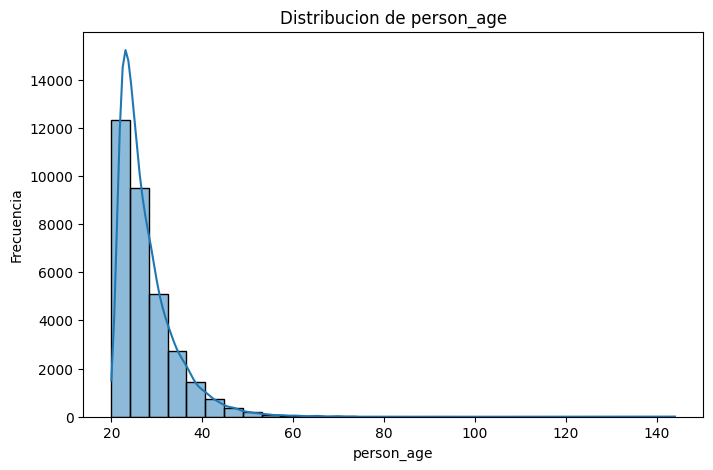

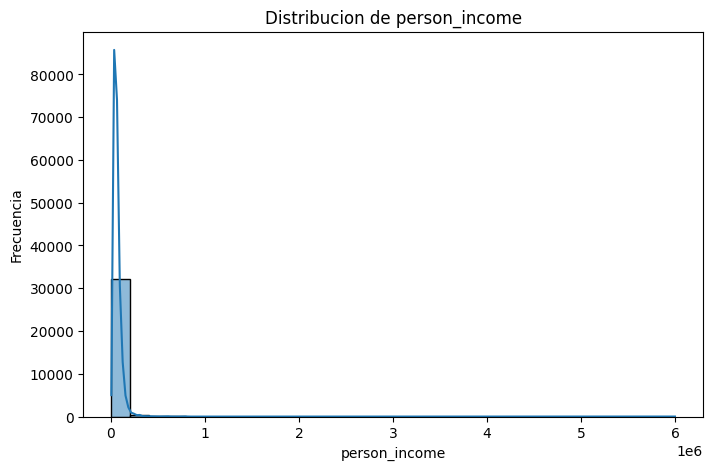

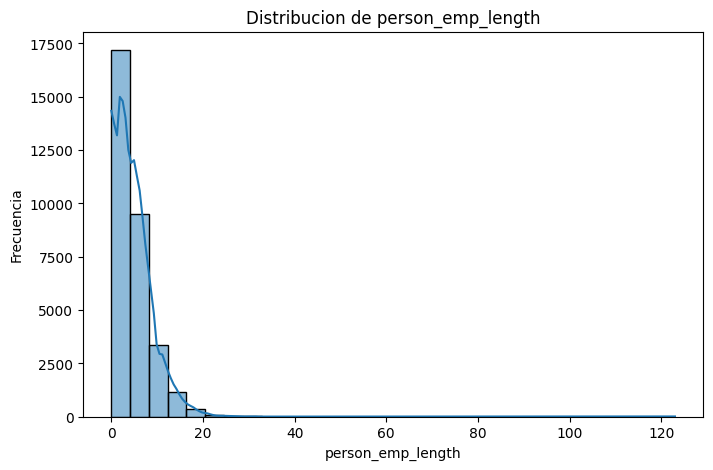

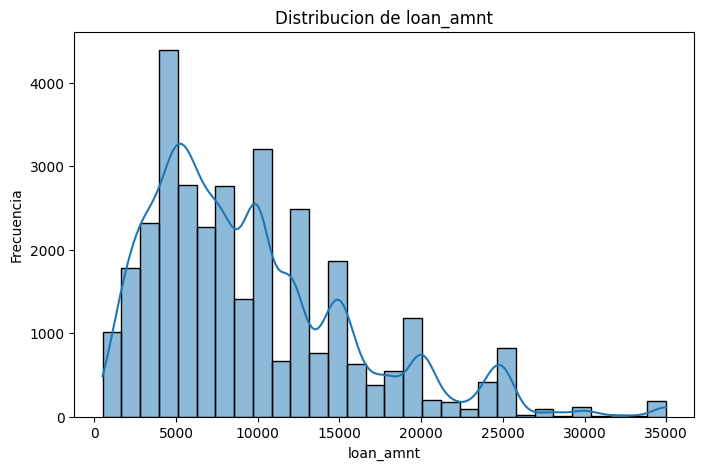

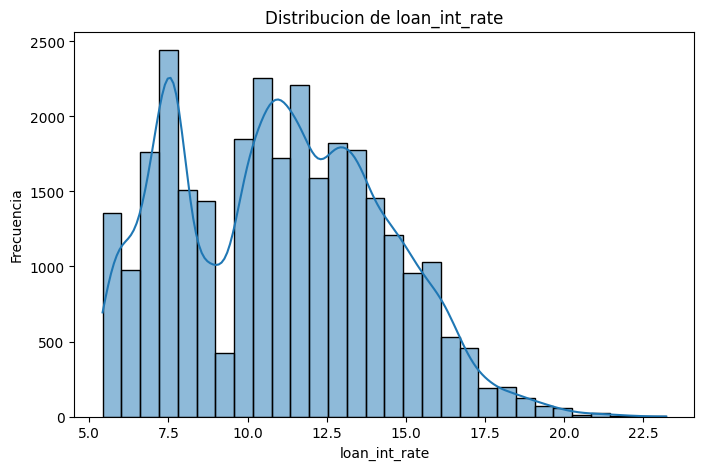

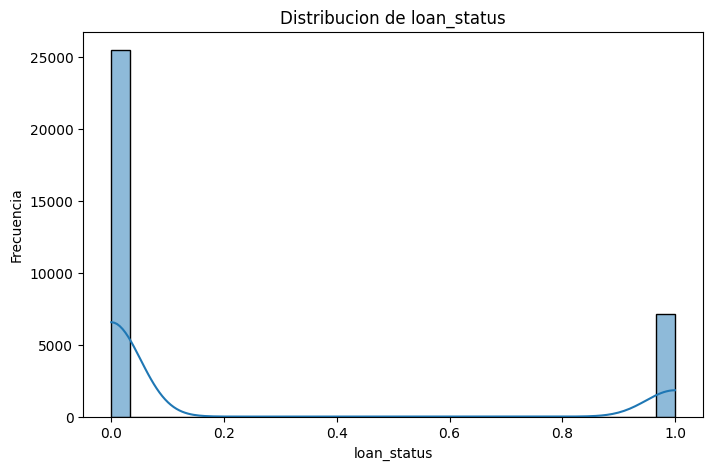

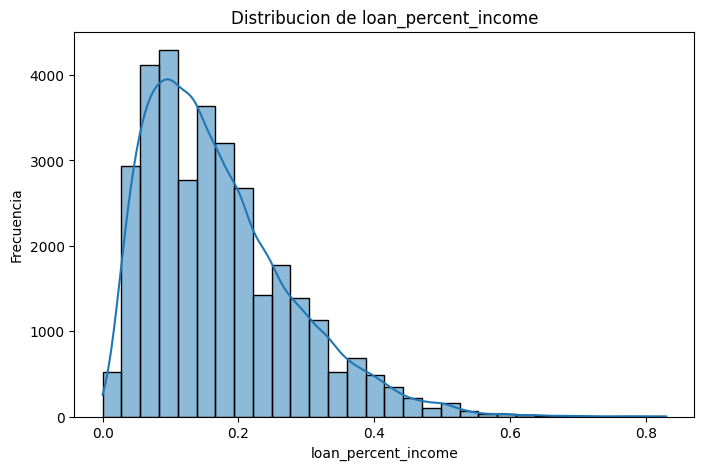

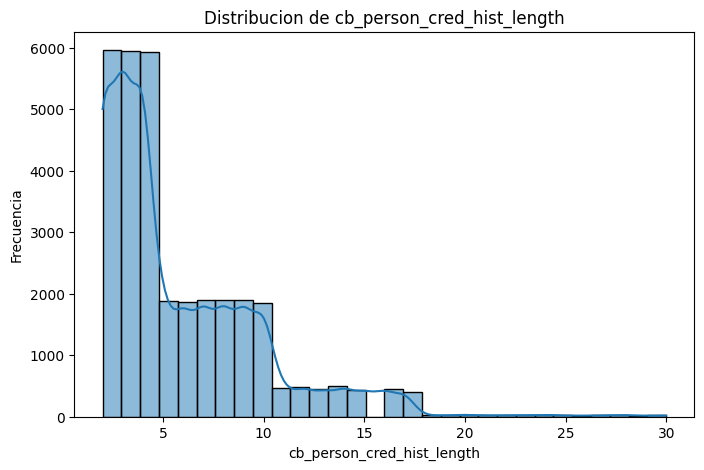

In [14]:
# Histogramas
for columna in num.columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=credit_df,
        x=columna,
        bins=30,
        kde=True
    )

    plt.title(f'Distribucion de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.show()

----

5. Emplea boxplots para mostrar la distribución de los datos a través de sus cuartiles.

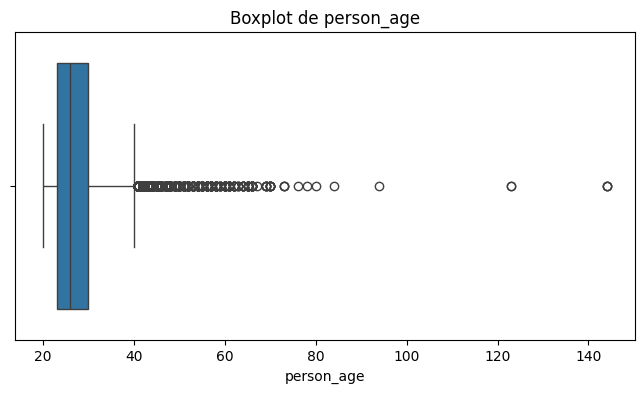

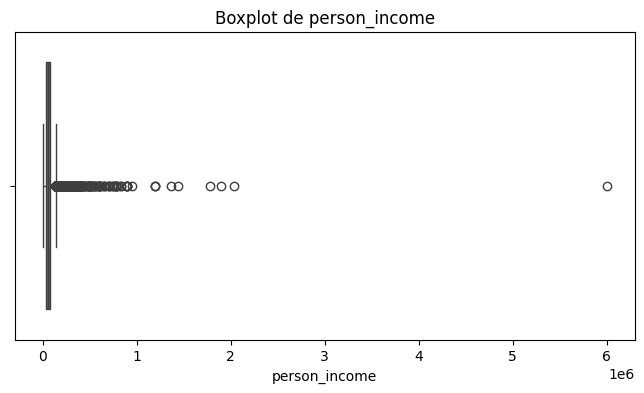

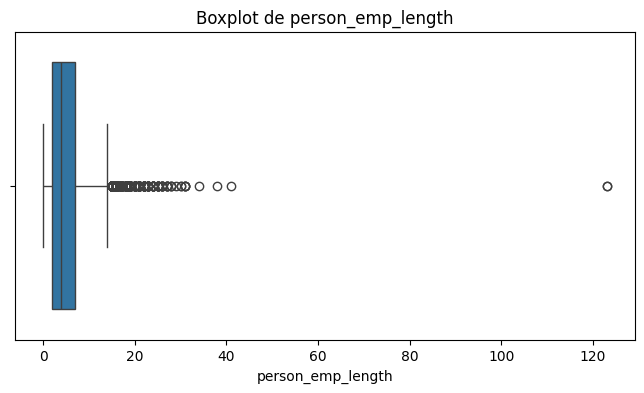

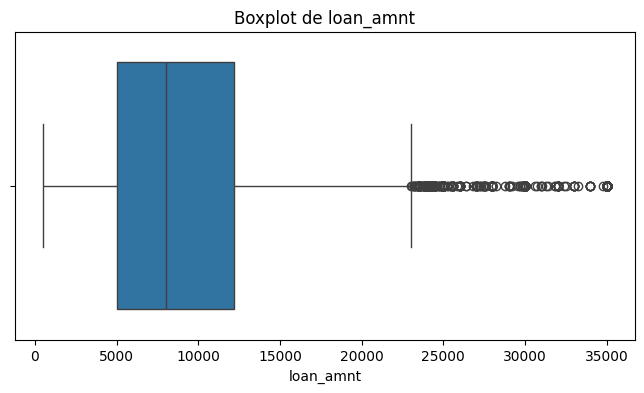

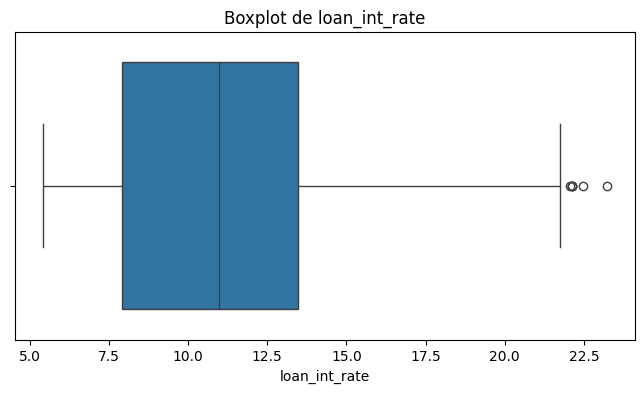

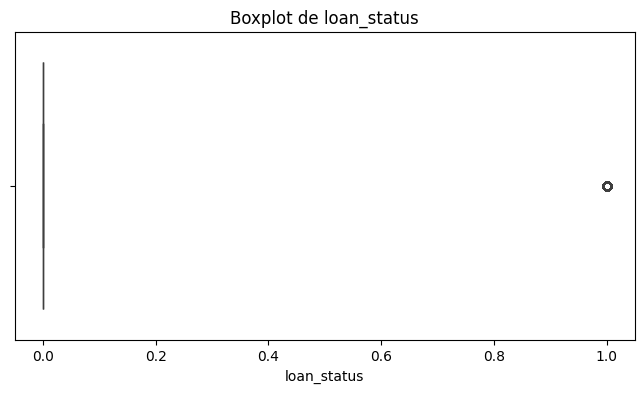

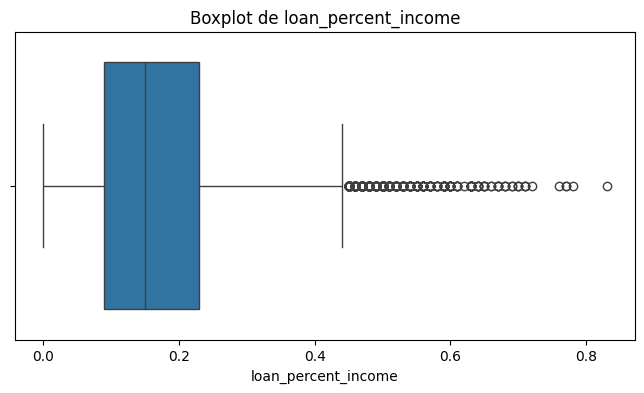

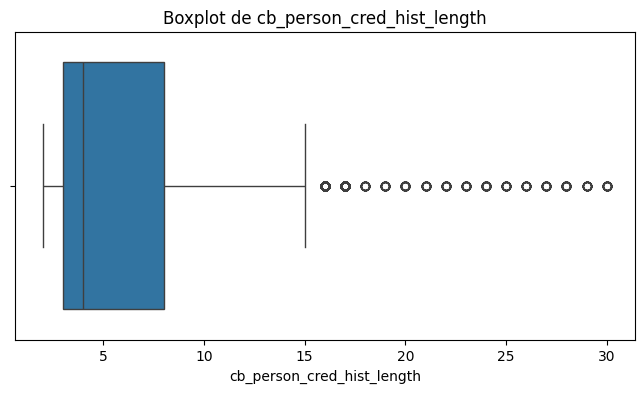

In [16]:
#Boxplots
for columna in num.columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=credit_df,
        x=columna
    )

    plt.title(f'Boxplot de {columna}')
    plt.xlabel(columna)
    plt.show()

-----

*   Como podrás observar hay valores atípicos en todas las variables. Ejecuta el siguiente código para identificar los valores atípicos en la variable `person_age`

**Interpretación Resultados**

<FONT COLOR="ORANGE">Los boxplots muestran que algunas variables tienen bastantes valores atipicos, sobre todo person_age y person_income. Esto quiere decir que hay datos bastante alejados de donde se concentra la mayoria. Usando el metodo del rango intercuartilico se encontraron 1,494 valores atípicos en person_age</FONT>

In [17]:
#COMENTE CADA LINEA DE CODIGO EXPLICANDO SU USO
# Calcular el primer cuartil (25%)
percentile_25 = credit_df["person_age"].quantile(0.25)

# Calcular el tercer cuartil (75%)
percentile_75 = credit_df["person_age"].quantile(0.75)

# Calcular el rango intercuartilico (IQR)
iqr = percentile_75 - percentile_25

# Calcular el limite superior
upper_limit = percentile_75 + 1.5 * iqr

# Calcular el limite inferior
lower_limit = percentile_25 - 1.5 * iqr

# Seleccionar las observaciones que están fuera de los limites
IQR_outliers = credit_df[
    (credit_df["person_age"] < lower_limit) |
    (credit_df["person_age"] > upper_limit)
]

# Mostrar limites
print("Límite inferior:", lower_limit)
print("Límite superior:", upper_limit)

# Mostrar valores atipicos
IQR_outliers

Límite inferior: 12.5
Límite superior: 40.5


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.69,0,0.03,N,15
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


-----

# Análisis de variables de texto

 6. Obtén las siguientes estadísticas descriptivas para todas las variables de texto:
*   Tendencia central (moda)
*   Cardinalidad (cantidad de valores únicos)
*   Recuentos únicos (número de ocurrencias para cada valor único)

**NOTA**. Un resumen de estas estadísticas, puedes obtenerlas indicando en la función `describe()` que se incluirán sólo las variables de tipo object: `describe(include = 'object')`. Para los recuentos utiliza la función `df['columna'].value_counts()`

In [18]:
#IDENTIFIQUE CUALES SON LAS VARIABLES DE TEXTO
texto = credit_df.select_dtypes(include='object')

print("Variables cualitativas:")
print(list(texto.columns))

texto.describe()


Variables cualitativas:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [19]:
#Moda
texto.mode().iloc[0]

,0
person_home_ownership,RENT
loan_intent,EDUCATION
loan_grade,A
cb_person_default_on_file,N


In [20]:
#Cardinalidad
texto.nunique()

,0
person_home_ownership,4
loan_intent,6
loan_grade,7
cb_person_default_on_file,2


In [21]:

#Recuento
for columna in texto.columns:
    print(f"\nVariable: {columna}")

    resumen = pd.DataFrame({
        'Frecuencia': credit_df[columna].value_counts(),
        'Porcentaje (%)': credit_df[columna].value_counts(normalize=True) * 100
    })

    print(resumen)



Variable: person_home_ownership
                       Frecuencia  Porcentaje (%)
person_home_ownership                            
RENT                        16446       50.477272
MORTGAGE                    13444       41.263313
OWN                          2584        7.931003
OTHER                         107        0.328412

Variable: loan_intent
                   Frecuencia  Porcentaje (%)
loan_intent                                  
EDUCATION                6453       19.806022
MEDICAL                  6071       18.633559
VENTURE                  5719       17.553175
PERSONAL                 5521       16.945459
DEBTCONSOLIDATION        5212       15.997053
HOMEIMPROVEMENT          3605       11.064731

Variable: loan_grade
            Frecuencia  Porcentaje (%)
loan_grade                            
A                10777       33.077561
B                10451       32.076977
C                 6458       19.821368
D                 3626       11.129186
E                  9

-----

7. Utiliza gráficos de barras por variable para representar la frecuencia de cada categoría.

**NOTA**. seaborn posee un gráfico de recuento, para variables de tipo object, que calcula la frecuencia de cada categoría sin necesidad de utilizar la función `value_counts()`. Para generarlo debes indicar la columna: `sns.countplot(x='columna', data=df) `

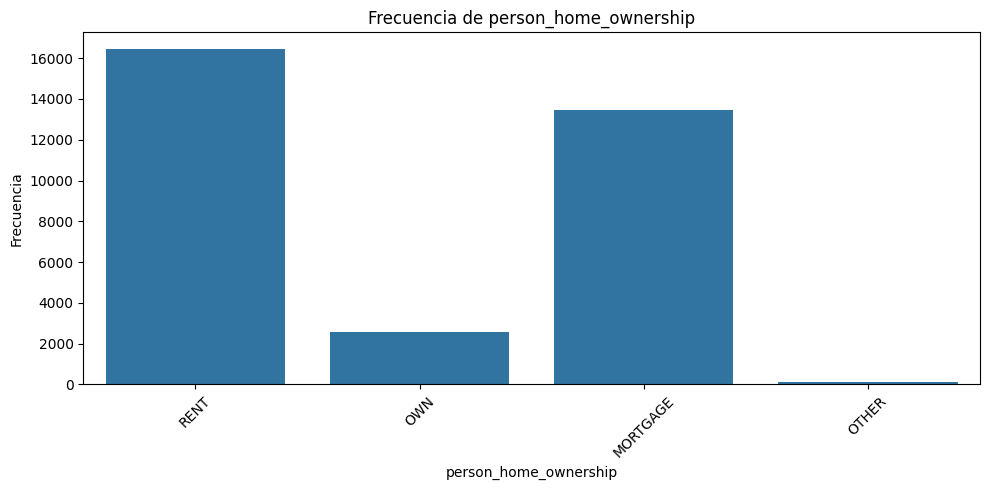

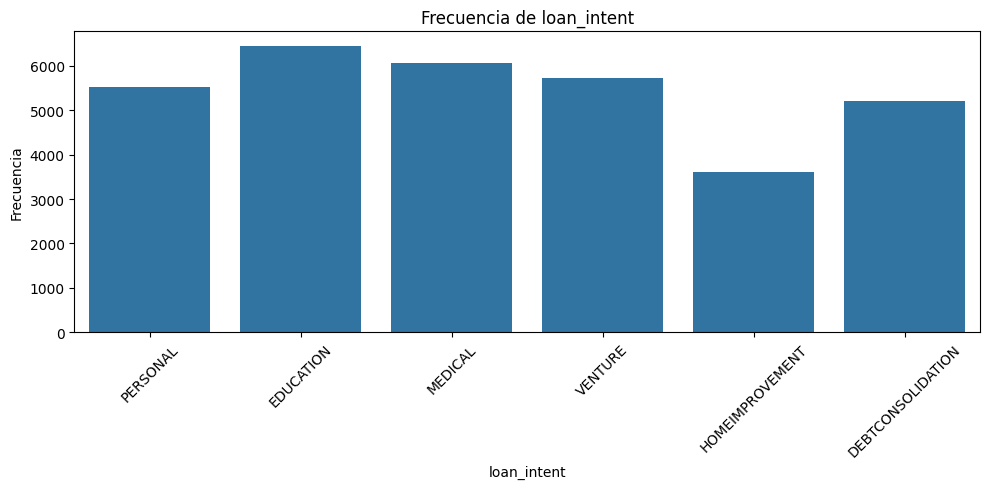

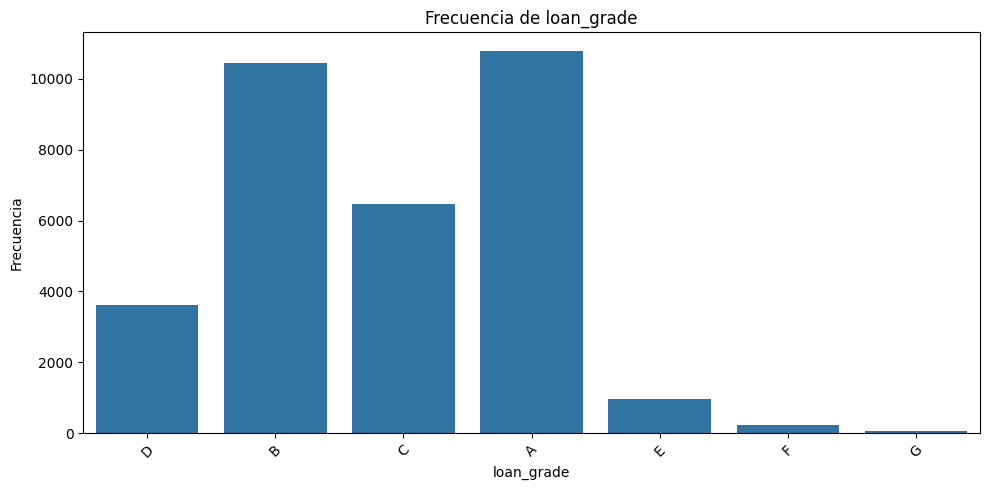

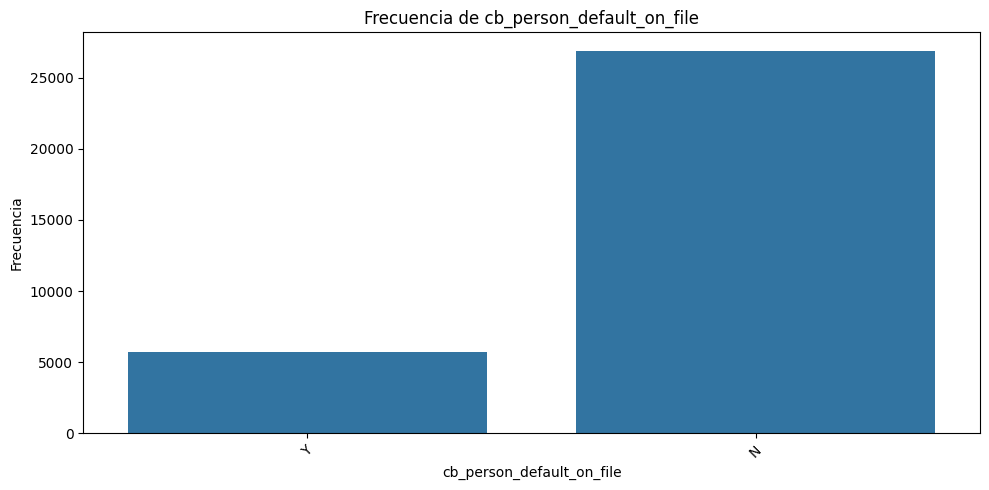

In [22]:
for columna in texto.columns:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=credit_df,
        x=columna
    )

    plt.title(f'Frecuencia de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

-----

# **Parte 2**. Análisis de correlación (bivariante y multivariante)

La variable `loan_status` será la variable de salida (o a predecir en un modelo de ML). Analiza su relación con el resto de las variables a través de los siguientes gráficos:

8. Un box plot para visualizar la distribución de `loan_percent_income` según el `loan_status`. Interpreta el resultado.

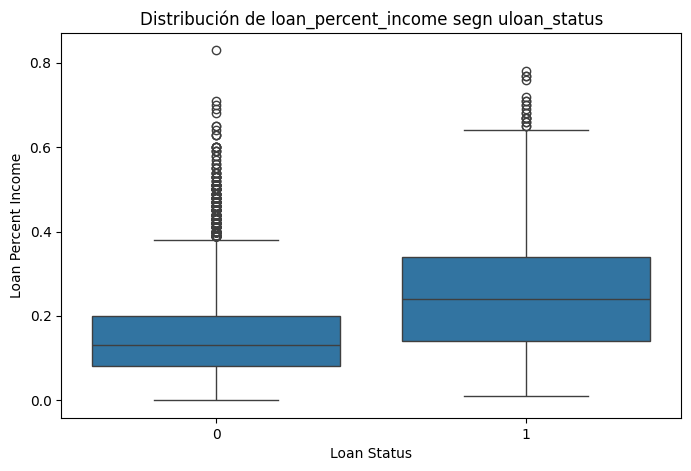

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.0,0.148805,0.087252,0.00,0.08,0.13,0.20,0.83
1,7108.0,0.246889,0.132148,0.01,0.14,0.24,0.34,0.78


In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=credit_df,
    x='loan_status',
    y='loan_percent_income'
)

plt.title('Distribución de loan_percent_income segn uloan_status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percent Income')
plt.show()
credit_df.groupby('loan_status')['loan_percent_income'].describe()

**Interpretación resultados**

<FONT COLOR="ORANGE">Se puede ver una diferencia clara entre los dos grupos. Para loan_status = 0, la mediana de loan_percent_income es aproximadamente 0.13, mientras que para loan_status = 1 es 0.24. Esto indica que cuando el prestamo representa una mayor parte del ingreso de la persona, hay mas relación con un estado de prestamo igual a 1.</FONT>



 9. En los gráficos de barras que obtuviste en el ejercicio 7, separa el conteo según el `load_status`, utilizando el parámetro `hue`.

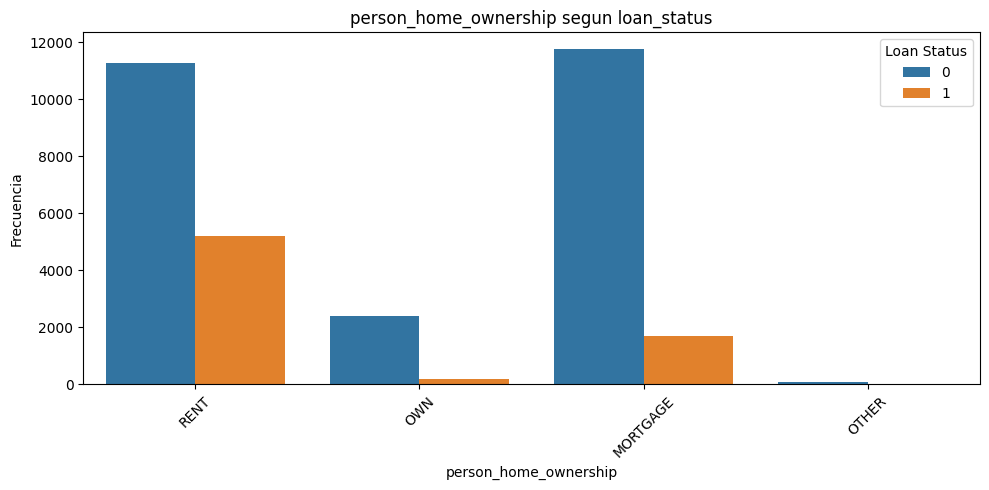

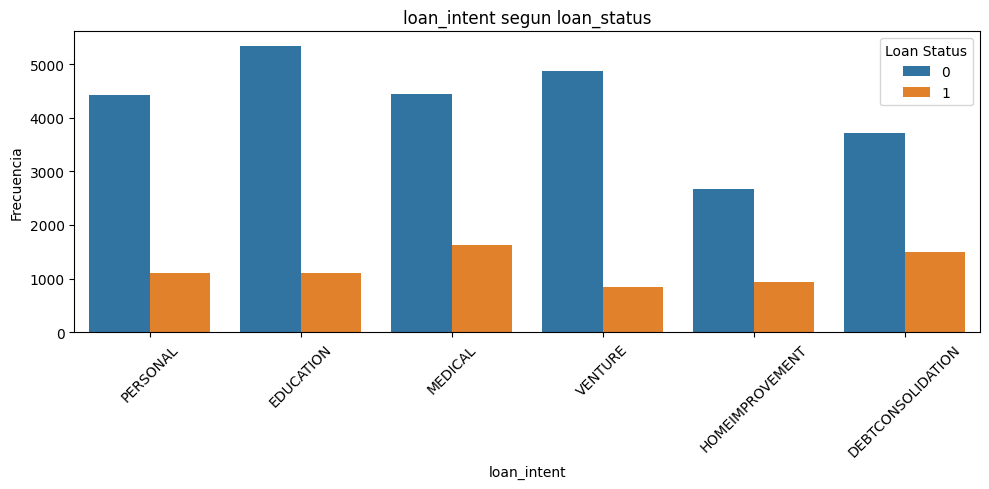

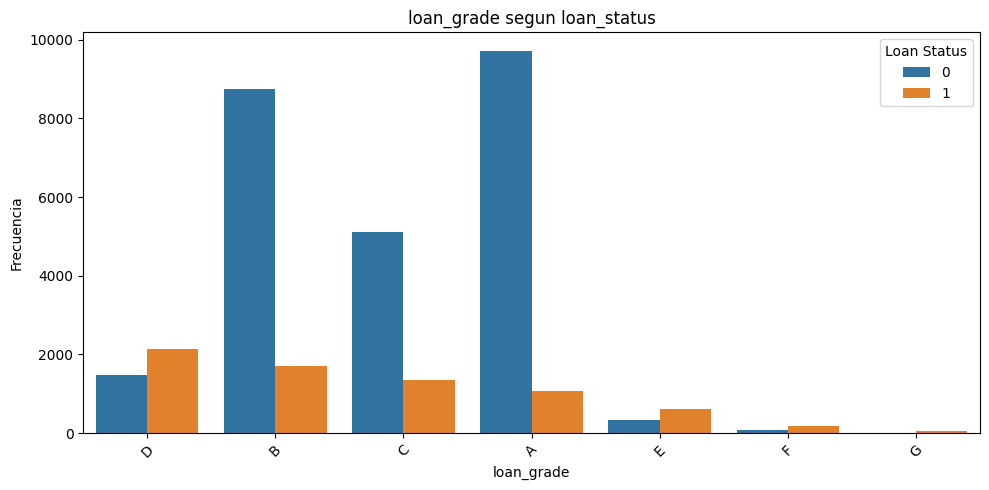

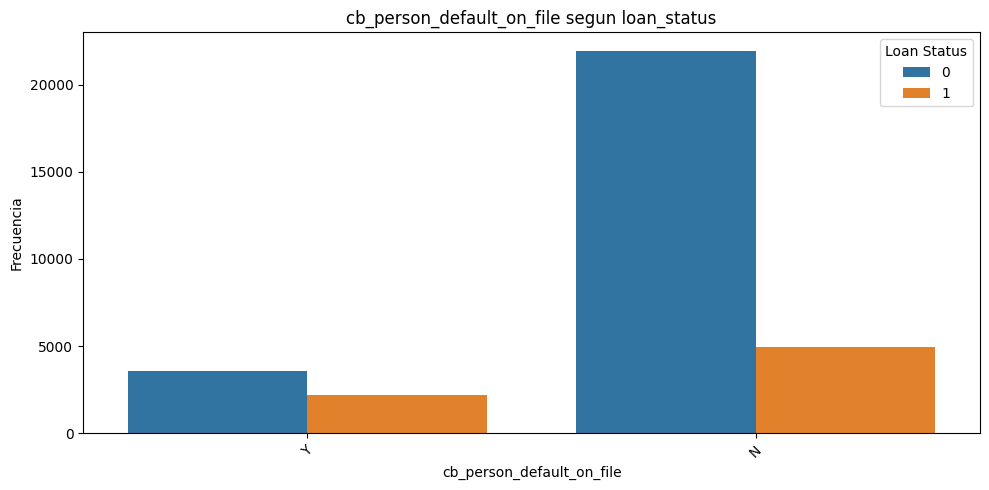

In [24]:
for columna in texto.columns:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=credit_df,
        x=columna,
        hue='loan_status'
    )

    plt.title(f'{columna} segun loan_status')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.legend(title='Loan Status')
    plt.tight_layout()
    plt.show()

10. Un mapa de calor con los valores de correlación de todas las variables del dataframe.
*   ¿Qué variable tiene mayor correlación con `loan_status`?

**Respuesta a pregunta**

<FONT COLOR="ORANGE">La variable con mayor correlacion con loan_status es loan_percent_income, con aproximadamente 0.38, seguida de loan_int_rate, con alrededor de 0.34. Esto indica que estas dos variables tienen una relacion positiva moderada con el estado del préstamo, aunque ninguna tiene una correlacion extremadamente fuerte.</FONT>



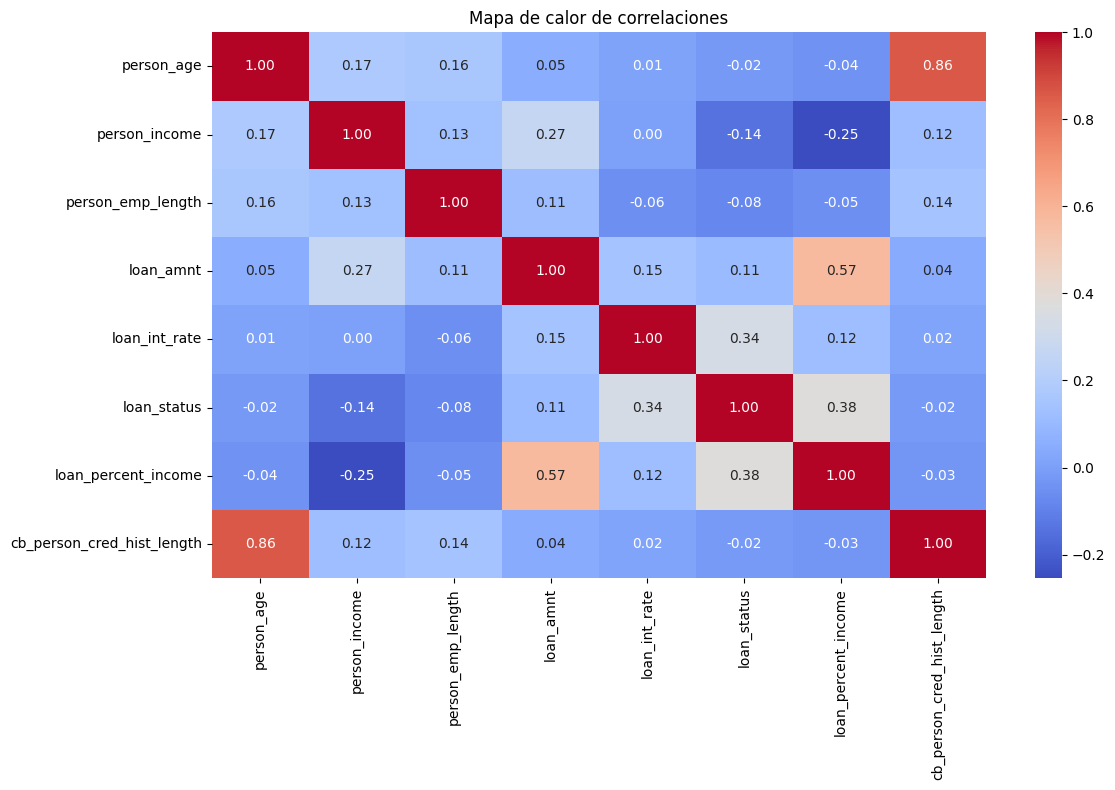

In [25]:
#CODIGO PARA MAPA DE CALOR
# Seleccionar variables numericas
numeric_df = credit_df.select_dtypes(include=np.number)

# Calcular matriz de correlacion
correlation_matrix = numeric_df.corr()

# Crear mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de calor de correlaciones')
plt.tight_layout()
plt.show()